# Prepare gRNAde Designs for Eterna OpenKnot Benchmark Submission

This notebook performs final selection and formatting of gRNAde designs for submission to the **Eterna OpenKnot Benchmark** competition, where they are experimentally validated at Stanford University.

## Submission Workflow

1. **Load generated designs**: Import CSV from `design.ipynb` (~100,000 passing designs)
2. **Optionally apply secondary structure filtering**: E.g. RNet-SS self-consistency ≥ 0.9 (MCC)
3. **Rank by OpenKnot Score**: Sort designs by predicted SHAPE reactivity match
4. **Select top designs**: 20 designs per puzzle for experimental synthesis
5. **Format for Eterna**: Generate TSV file compatible with Eterna submission portal
6. **Visualize predictions**: Plot predicted reactivity profiles for quality control

In [1]:
# Import libraries and set up the environment

import sys
sys.path.append('../../')

import dotenv
dotenv.load_dotenv("../../.env")

import os
import numpy as np
import pandas as pd

# Load Target Puzzle Metadata

- **PUZZLE_IDX**: Select same puzzle as in `design.ipynb` (0-19)
- **PUZZLE_SET**: Round 7a (Round 3 in paper) or 7b (Round 4 in paper)
- **MODE**: `'2d'` or `'3d'` design mode used during generation

In [2]:
# OpenKnot settings 
PUZZLE_IDX = 1  # 0-19
PUZZLE_SET = 'a' # 'a' or 'b'
MODE = '2d'    # '2d' or '3d'

df = pd.read_csv(f'metadata_7{PUZZLE_SET}.csv')
puzzle_id = list(df["puzzleID"].values)[PUZZLE_IDX]
title = list(df["Title"].values)[PUZZLE_IDX]
source = list(df["Source"].values)[PUZZLE_IDX]
native_seq = list(df["Sequence"].values)[PUZZLE_IDX]
target_sec_struct = list(df["Dot-bracket"].values)[PUZZLE_IDX]
print(f"puzzle_id: {puzzle_id}")
print(f"title: {title}")
print(f"source: {source}")
print(f"native_seq: {native_seq}")
print(f"target_sec_struct: {target_sec_struct}")

puzzle_id: 13620852
title: ZTP switch
source: 5BTP
native_seq: UAUCAGUUAUAUGACUGACGGAACGUGGAAUUAACCACAUGAAGUAUAACGAUGACAAUGCCGACCGUCUGGGCG
target_sec_struct: .....(((((((..(.[[[[[...((((......))))..)..))))))).........(((..]]]]]..))).


# Filter and Rank Designs

Apply final quality control filters before experimental submission:

## Loading and Deduplication
- Load all designs from `design.ipynb` (typically ~100,000 passing initial threshold)
- Remove duplicate sequences to ensure unique experimental candidates
- Sort by predicted OpenKnot Score (highest first)

## Secondary Structure Filter
- **Threshold**: `sc_score_ribonanzanet_ss ≥ 0.9`
- **Adjustment**: Threshold can be reduced if insufficient designs pass (puzzle-dependent)

In [3]:
# Filter settings (reduce if needed, depending on target)
SEC_STRUCT_FILTER_THRESHOLD = 0.

# Load all designs
all_designs_df = pd.read_csv(f"designs/{puzzle_id}_{MODE}.csv")
print("Total designs:", len(all_designs_df))
# remove duplicate sequences
all_designs_df = all_designs_df.drop_duplicates(subset="sequence")
print("Unique designs:", len(all_designs_df))
# sort by openknot_score
all_designs_df = all_designs_df.sort_values(by="openknot_score", ascending=False)
# remove designs with sc_score_ribonanzanet_ss < threshold
df_subset = all_designs_df[all_designs_df["sc_score_ribonanzanet_ss"] >= SEC_STRUCT_FILTER_THRESHOLD]
print(f"Designs with sc_score_ribonanzanet_ss >= {SEC_STRUCT_FILTER_THRESHOLD}:", len(df_subset))
print("Max. openknot_score:", all_designs_df["openknot_score"].max())
df_subset

Total designs: 66211
Unique designs: 66211
Designs with sc_score_ribonanzanet_ss >= 0.0: 66162
Max. openknot_score: 100.0


,fasta_desc,sequence,model,id,seed,temperature,perplexity,openknot_score,sc_score_ribonanzanet_ss
27525,gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13...,GGUUACCCGGUGAAGUGCAGAGCUACAGUUAAAACUGUGACAUCAC...,gRNAde2_drop3d@0.75_maxlen@500.h5,13620852,42,0.3,2.238125,100.000000,0.866213
48399,gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13...,GGUUACGUUGCAAAGUCCUGGAGUAGCGUCCAAACGCUUACACUGC...,gRNAde2_drop3d@0.75_maxlen@500.h5,13620852,42,0.5,2.257187,100.000000,0.848544
19699,gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13...,CCAUUCCCGGUGCAGUCCGAGUAACACGCUCCUACGUGAGAAACAC...,gRNAde2_drop3d@0.75_maxlen@500.h5,13620852,42,0.4,2.223150,99.333333,0.877419
11799,gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13...,GUUUGUCCCGUUCAGAGCCGGUUAAGCGAUUAAACGCUAUCUAAAC...,gRNAde2_drop3d@0.75_maxlen@500.h5,13620852,42,0.3,2.290319,99.333333,0.828265
28211,gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13...,GCGUGGCCCGUGGAGUGCGGCUGCCAGGUUCAAACCUGAACAUCAC...,gRNAde2_drop3d@0.75_maxlen@500.h5,13620852,42,0.4,2.182648,99.333333,0.905089
...,...,...,...,...,...,...,...,...,...
15203,gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13...,GCUUUCCCGGUAAAGAGCCAAGAAGCCGUUCAAACGGCAGCAAUAC...,gRNAde2_drop3d@0.75_maxlen@500.h5,13620852,42,0.1,1.979732,90.000000,0.949642
44472,gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13...,GAUUAUUUUUUUAAGAGCUCAAAAGCCAAGAAAAUGGCAGCUUGAA...,gRNAde2_drop3d@0.75_maxlen@500.h5,13620852,42,0.3,2.188728,90.000000,0.857058
44474,gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13...,GUCUUCCCCGUAGAGCUCCGAAAAGCCGUGAAAACGGCAACAAUAC...,gRNAde2_drop3d@0.75_maxlen@500.h5,13620852,42,0.3,2.171042,90.000000,0.227238
44479,gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13...,GUCUCGGCGCGAAAGUGCGAAGUUAGCGUGAAAACGCUGGAAAUCG...,gRNAde2_drop3d@0.75_maxlen@500.h5,13620852,42,0.3,2.138458,90.000000,0.866213


# Format Top Designs for Eterna Submission

Generate TSV-formatted output for the Eterna web portal. Each line contains three tab-separated fields:
1. **sequence**: RNA nucleotide sequence (A/G/C/U)
2. **title**: Design identifier (e.g., `gRNAde2d_design1`)
3. **description**: Metadata string with computational scores and parameters

In [4]:
# Iterate over designs and print top 20 designs as TSV for submission to Eterna
print("sequence\ttitle\tdescription")
sequences = []
designs = []
for count, (df_idx, row) in enumerate(df_subset.iterrows()):
    sequences.append(row["sequence"])
    design = f'{row["sequence"]}\tgRNAde{MODE}_design{count+1}\t{row["fasta_desc"]} openknot_round=7{PUZZLE_SET} mode={MODE}'
    designs.append(design)
    print(design)
    if count == 19:
        break

sequence	title	description
GGUUACCCGGUGAAGUGCAGAGCUACAGUUAAAACUGUGACAUCACCGGGUUCACAAUCCGGACUCUGCAUCCGA	gRNAde2d_design1	gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13620852 seed=42 temperature=0.3 perplexity=2.2381 openknot_score=100.0000 sc_score_ribonanzanet_ss=0.8662 openknot_round=7a mode=2d
GGUUACGUUGCAAAGUCCUGGAGUAGCGUCCAAACGCUUACACUGCAACGUUCAAAAUUCCCAGCCAGGUAGGGA	gRNAde2d_design2	gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13620852 seed=42 temperature=0.5 perplexity=2.2572 openknot_score=100.0000 sc_score_ribonanzanet_ss=0.8485 openknot_round=7a mode=2d
CCAUUCCCGGUGCAGUCCGAGUAACACGCUCCUACGUGAGAAACACCGGGUUCCAAUUUCGGUACUCGGCACCGA	gRNAde2d_design3	gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13620852 seed=42 temperature=0.4 perplexity=2.2232 openknot_score=99.3333 sc_score_ribonanzanet_ss=0.8774 openknot_round=7a mode=2d
GUUUGUCCCGUUCAGAGCCGGUUAAGCGAUUAAACGCUAUCUAAACGGGAAUUAAAAUUCUCAACCGGCAAGAGA	gRNAde2d_design4	gRNAde2_drop3d@0.75_maxlen@500.h5 puzzle_id=13620852 seed=42 temperatur

# Visualize Predicted Reactivity Profiles

Generate quality control heatmap showing predicted SHAPE reactivity using RibonanzaNet for submitted designs:

**Expected reactivity patterns** (for correct folds):
- **Unpaired regions** (`.` in dot-bracket): High reactivity (red)
- **Paired regions** (`()[]` in dot-bracket): Low reactivity (white)
- **Pseudoknots** (`[]`): Low reactivity

Using device: cuda:0
Loading RibonanzaNet checkpoint: /home/ckj24/gRNAde_2/tools/ribonanzanet/ribonanzanet.pt

Predicted OpenKnot scores: [100.         100.          99.33333333  99.33333333  99.33333333
  99.33333333  99.33333333  99.33333333  99.33333333  99.33333333
  99.33333333  99.33333333  99.33333333  99.33333333  99.33333333
  99.33333333  99.33333333  99.33333333  99.33333333  99.33333333]


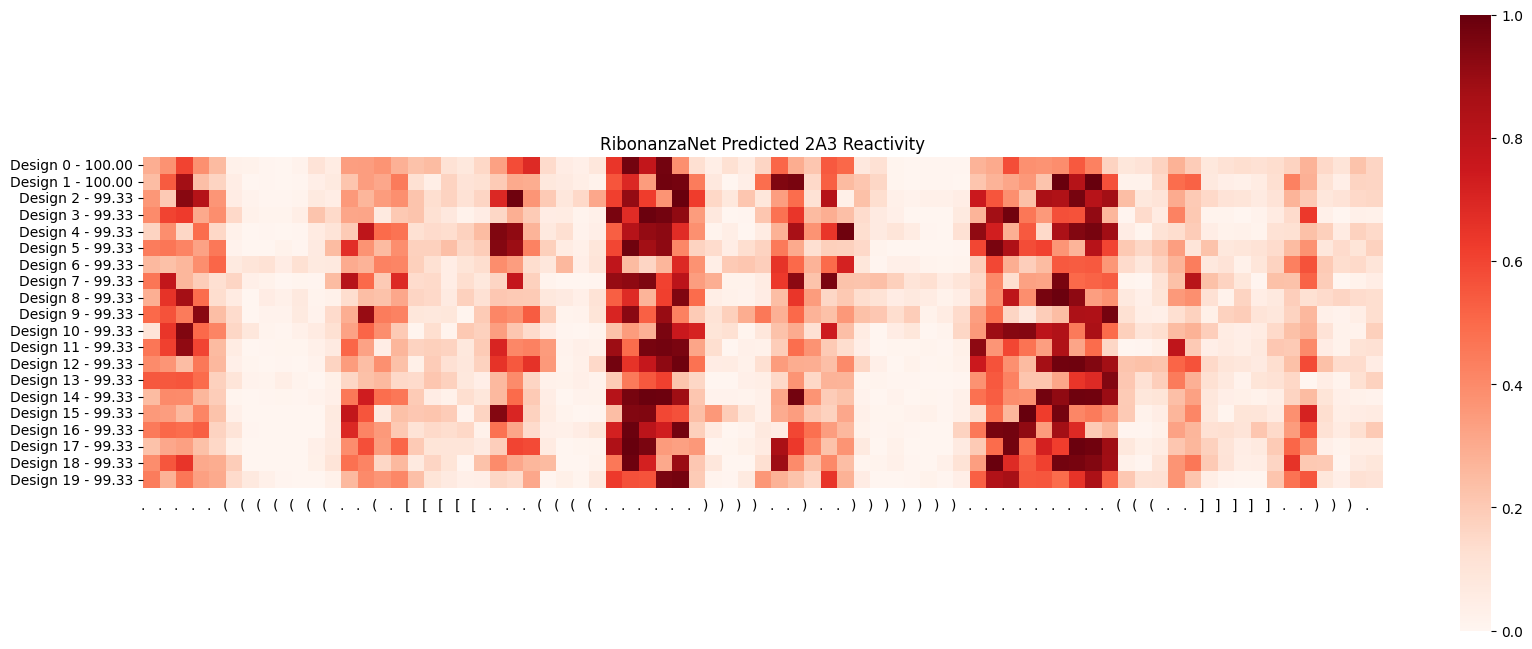

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from src.openknot_score import get_openknot_score
from src.constants import NUM_TO_LETTER, LETTER_TO_NUM, PROJECT_PATH, DATA_PATH, FILL_VALUE

from tools.ribonanzanet.network import RibonanzaNet

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialise RibonanzaNet for 1D self-consistency score
ribonanza_net = RibonanzaNet(
    os.path.join(PROJECT_PATH, 'tools/ribonanzanet/config.yaml'),
    os.path.join(PROJECT_PATH, 'checkpoints/ribonanzanet/ribonanzanet.pt'),
    device
)
# Transfer model to device in eval mode
ribonanza_net = ribonanza_net.to(device)
ribonanza_net.eval()
print()

# predict chemical modification using RibonanzaNet
pred_chem_mods = ribonanza_net.predict(sequences).cpu().numpy()[:, :, 0]

# compute openknot scores
_, _, _, openknot_scores = get_openknot_score(
    target_sec_struct,
    pred_chem_mods,
)
print("Predicted OpenKnot scores:", openknot_scores)

# plot predicted and groundtruth chemical modification
plt.figure(figsize=(20, 8))
_df = {}
for i in range(len(pred_chem_mods)):
    _df[f"Design {i} - {openknot_scores[i]:.2f}"] = pred_chem_mods[i]
sns.heatmap(
    pd.DataFrame(_df).transpose(),
    cmap="Reds",
    vmin=0.0,
    vmax=1.0,
    square=True,
)
plt.title(f"RibonanzaNet Predicted 2A3 Reactivity")
# replace x-ticks with true secondary structure
plt.xticks(np.arange(len(target_sec_struct)), target_sec_struct)
# rotate x-ticks
plt.xticks(rotation=0)
# remove x-tick marks
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=True   # labels along the bottom edge are off
)
plt.show()